## CMPE-257, Machine Learning, Summer 2025
## Week 1: Introduction to Machine Learning
In this workbook, you will be exploring the perceptron learning algorithm:
- the perceptron as a binary classifier
- convergence and the learning rate parameter
- term project ideas... 

In [1]:
# YOUR NAME: <enter your name here>

In [2]:
# Loading required modules
import random as rd
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

## PART 1: The Perceptron as a Binary Classifier

In [3]:
# The following three functions provide the basis for the exporatory work you will be
# conducting in this coding session, study them and make sure you understand what they do

# PLA_MSE: computes the mean square error over a given set of data samples
# - dtn: set of data samples (list of numpy arrays)
# - tgt: set of traget values (list)
# - model: the perceptron weights (numpy array)

def pla_mse(dtn,tgt,model):  
    tst = []
    for xt in dtn:
        tst.append(np.sign(sum(xt*model)))
    return sum([(x-y)**2 for x,y in zip(tst,tgt)])/len(tgt)

# PLA_TRAIN: implements the perceptron learning algorithm
# - dtx: set of data samples (list of lists)
# - tgt: set of traget values (list)
# - wgt: initial set of weights (list of len=3) or weights are ramdomly generated
# - seq: data sequence (list of len>0) or sequence is randomly generated
# - nsteps: the maximum number of iterations (int)
# - thld: error threshold for algorithm termination
# note: this script assumes a linear classifier in 2D space (three weights only)

def pla_train(dtx,tgt,wgt,seq,nsteps=1000,thld=0.001):
    
    # initialization step
    data = [np.array(xn) for xn in [[1]+xy for xy in dtx]]
    target = tgt.copy()    
    if len(wgt)==3: wt = [np.array(wgt)]
    else: wt = [np.array([rd.uniform(-3.0,3.0) for x in range(3)])]
    if len(seq)>0: nvals = seq.copy()
    else: nvals = [rd.randint(0,len(data)-1) for x in range(nsteps)]
    mse = [pla_mse(data,target,wt[-1])]
    
    # perceptron learning algorithm
    for k,n in enumerate(nvals):    
        if mse[-1]<thld: break
        xt = data[n]
        yt = np.sign(sum(xt*wt[-1]))
        error = yt - target[n]
        if error == 0.0: continue
        new = wt[-1] - error*xt
        wt.append(new)
        mse.append(pla_mse(data,target,wt[-1]))
        if mse[-1]<thld: break
            
    # stores the training history into a data frame
    platrn = pd.DataFrame(np.array(wt),columns=['W0','W1','W2'])
    platrn['slope'] = -platrn['W1'].values/platrn['W2'].values
    platrn['intercept'] = -platrn['W0'].values/platrn['W2'].values
    platrn['mse'] = mse
    return platrn

# PLA_PLOT: creates plots for a given training-history data frame
# - dtx: set of data samples (list of lists)
# - tgt: set of traget values (list)
# - pla_df: the training-history data frame (output from PLA_TRAIN)
# note: this script also assumes a linear classifier in 2D space (three weights only)

def pla_plots(dtx,tgt,pla_df):

    fig, ax = plt.subplots(2,2,figsize=(10,8))

    # first plot: evelution of perceptron weights through the training steps
    wcols = [x for x in pla_df.columns.values if 'W' in x] 
    for col in wcols:
        ax[0,0].plot(pla_df[col].values,'*:',label=col)
    ax[0,0].legend()
    ax[0,0].set_title('Perceptron Weights')

    # second plot: evolution of the mean square error through the training steps
    ax[0,1].plot(pla_df['mse'].values,'*:',label='mse')
    ax[0,1].legend()
    ax[0,1].set_title('Mean Square Error')

    # third and fourth plot: initial and final classification boundaries with data points
    mark = ['*b' if x==1.0 else '*r' for x in tgt]
    for k in range(2):
        for n,xy in enumerate(dtx):
            ax[1,k].plot(xy[0],xy[1],mark[n])
    titles = ['Initial Model','Final Model']
    xvals = [x[0] for x in dtx]
    xx = np.arange(min(xvals)-1.0,max(xvals)+2.0)
    for n,k in enumerate([0,pla_df.shape[0]-1]):
        m = pla_df['slope'].values[k]
        b = pla_df['intercept'].values[k]
        tag = 'y = '+'{:6.3f}'.format(m)+' x + '+'{:6.3f}'.format(b)
        ax[1,n].plot(xx,[m*s+b for s in xx],'-',label=tag)
        ax[1,n].legend()
        ttl = titles[n]+' (MSE='+'{:6.3f}'.format(pla_df['mse'].values[k])+')'
        ax[1,n].set_title(ttl)
        

,W0,W1,W2,slope,intercept,mse
0,-3.0,0.0,2.0,-0.0,1.500000,1.0
1,-5.0,-8.0,-2.0,-4.0,-2.500000,2.0
2,-3.0,-6.0,4.0,1.5,0.750000,1.0
3,-1.0,0.0,12.0,-0.0,0.083333,2.0
4,-3.0,-8.0,8.0,1.0,0.375000,0.0


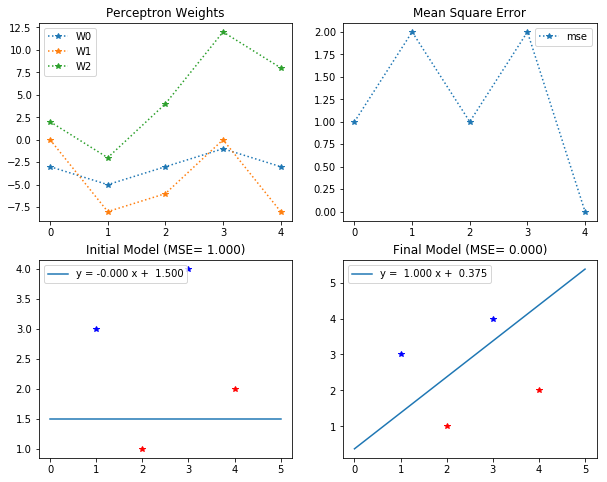

In [4]:
# Exercise #1: reproduce the example from class, display the results and generate the plots

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# initial set of weights 
weights = [-3.0,0.0,2.0]

# sample sequence to run the algorithm
sampleseq = [0,3,0,2,2,3]

training_table = pla_train(dataset,targets,weights,sampleseq)
display(training_table)

pla_plots(dataset,targets,training_table)

,W0,W1,W2,slope,intercept,mse
0,5.0,-1.0,-1.0,-1.000000,5.000000,2.00
1,3.0,-5.0,-3.0,-1.666667,1.000000,2.00
2,5.0,1.0,5.0,-0.200000,-1.000000,2.00
3,3.0,-3.0,3.0,1.000000,-1.000000,0.25
4,2.0,-5.0,2.0,2.500000,-1.000000,1.00
5,4.0,1.0,10.0,-0.100000,-0.400000,2.00
6,2.0,-3.0,8.0,0.375000,-0.250000,2.00
7,0.0,-11.0,4.0,2.750000,-0.000000,1.00
8,2.0,-5.0,12.0,0.416667,-0.166667,2.00
9,0.0,-9.0,10.0,0.900000,-0.000000,0.00


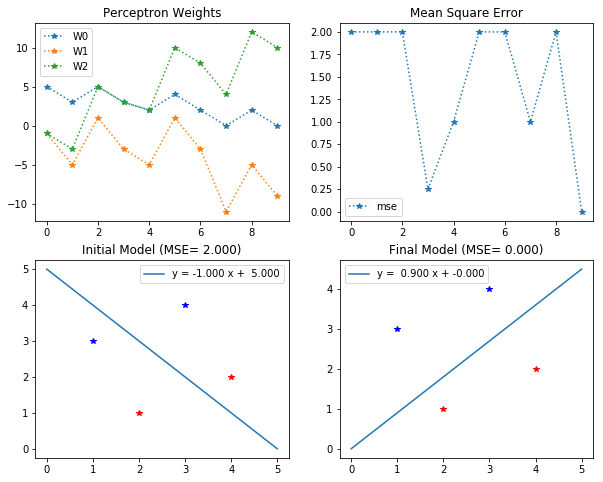

In [6]:
# Exercise #2: consider the new proposed set of weights and use a random sample sequence, 
# display the results and generate the plots 

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# the new initial set of weights  
weights = [5.0,-1.0,-1.0]

# forces for a random sequnece of samples 
sampleseq = []

# add your code here...
training_table = pla_train(dataset,targets,weights,sampleseq)
display(training_table)

pla_plots(dataset,targets,training_table)

,W0,W1,W2,slope,intercept,mse
0,-0.5,-0.7,1.0,0.7,0.5,0.0


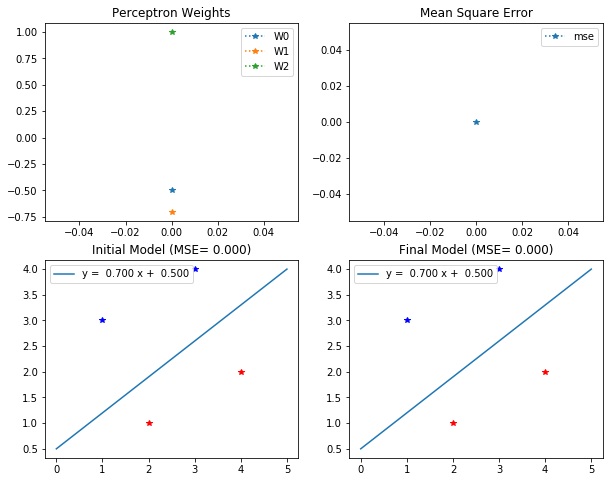

In [8]:
# Exercise #3: consider a new initial set of weights, display the results and generate the plots

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# the new initial set of weights  
weights = [-0.5,-0.7,1.0]

# forces for a random sequnece of samples 
sampleseq = []

# add your code here...
training_table = pla_train(dataset,targets,weights,sampleseq)
display(training_table)

pla_plots(dataset,targets,training_table)

,W0,W1,W2,slope,intercept,mse
0,0.5,0.7,-1.0,0.700000,0.500000,4.0
1,-1.5,-3.3,-3.0,-1.100000,-0.500000,2.0
2,0.5,-1.3,3.0,0.433333,-0.166667,2.0
3,-1.5,-9.3,-1.0,-9.300000,-1.500000,2.0
4,0.5,-7.3,5.0,1.460000,-0.100000,1.0
5,2.5,-1.3,13.0,0.100000,-0.192308,2.0
6,0.5,-9.3,9.0,1.033333,-0.055556,0.0


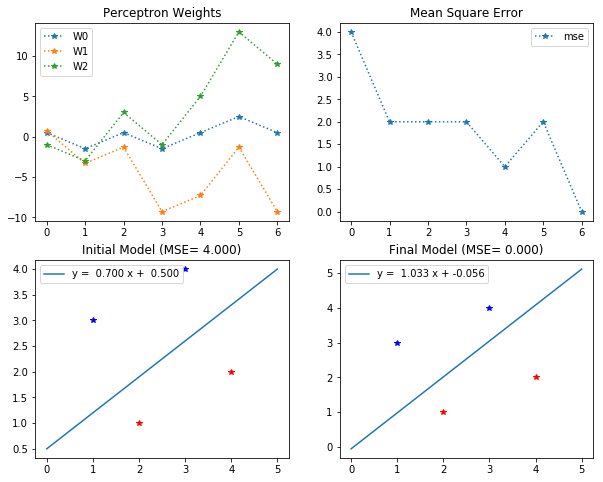

In [10]:
# Exercise #4: consider another initial set of weights, display the results and generate the plots

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# the new initial set of weights  
weights = [0.5,0.7,-1.0]

# forces for a random sequnece of samples 
sampleseq = []

# add your code here...
training_table = pla_train(dataset,targets,weights,sampleseq)
display(training_table)

pla_plots(dataset,targets,training_table)

## Part 2: Convergence and the Learning Rate Parameter

In [12]:
# Exercise #5: for the given initial conditions, repeat the training 20 times and print 
# the total number of iterations for each training run (i.e. training_table.shape[0])

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# initial set of weights 
weights = [-3.0,0.0,2.0]

# forces for a random sequnece of samples 
sampleseq = []

# add your code here...
niter = []
for repeat in range(20):
    niter.append(pla_train(dataset,targets,weights,sampleseq).shape[0])
display(niter)

[5, 5, 5, 10, 10, 5, 5, 10, 10, 10, 5, 10, 10, 5, 5, 10, 5, 10, 5, 5]

100%|████████████████████████████████████████████| 10000/10000 [00:39<00:00, 253.70it/s]


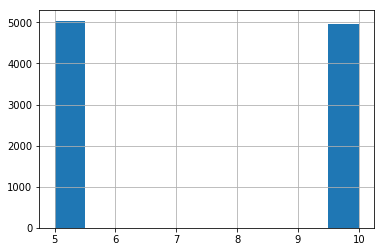

In [14]:
# Exercise #6: repeat 10K times and plot the histogram for the total number of iterations

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# initial set of weights 
weights = [-3.0,0.0,2.0]

# forces for a random sequnece of samples 
sampleseq = []

# add your code here...
niter = []
for repeat in tqdm(range(10000)):
    niter.append(pla_train(dataset,targets,weights,sampleseq).shape[0])
pd.DataFrame(niter)[0].hist()

100%|████████████████████████████████████████████| 10000/10000 [00:38<00:00, 262.12it/s]


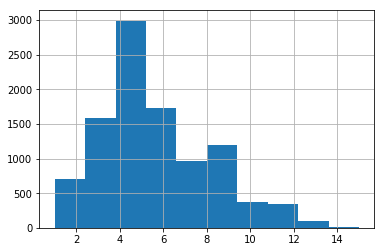

In [16]:
# Exercise #7: repeat again 10K times and plot the histogram but use random initial weights

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# forces for a random initial set of weights  
weights = []

# forces for a random sequnece of samples 
sampleseq = []

# add your code here...
niter = []
for repeat in tqdm(range(10000)):
    niter.append(pla_train(dataset,targets,weights,sampleseq).shape[0])
pd.DataFrame(niter)[0].hist()

In [18]:
# Exercise #8: use the PLA_TRAIN funtion in Part 1 to create the new funtion PlA_TRAIN_LR,
# which incorporates a new input parameter: lrate (learning rate). 

# Notice you only need to modify one line of code to incorporate the learning rate into the 
# perceptron learning algorithm, i.e. new = wt[-1] - lrate*error*xt

def pla_train_lr(dtx,tgt,wgt,seq,nsteps=1000,thld=0.001,lrate=1.0):
    
    # add your code here...
    # initialization step
    data = [np.array(xn) for xn in [[1]+xy for xy in dtx]]
    target = tgt.copy()    
    if len(wgt)==3: wt = [np.array(wgt)]
    else: wt = [np.array([rd.uniform(-3.0,3.0) for x in range(3)])]
    if len(seq)>0: nvals = seq.copy()
    else: nvals = [rd.randint(0,len(data)-1) for x in range(nsteps)]
    mse = [pla_mse(data,target,wt[-1])]
    
    # perceptron learning algorithm
    for k,n in enumerate(nvals):    
        if mse[-1]<thld: break
        xt = data[n]
        yt = np.sign(sum(xt*wt[-1]))
        error = yt - target[n]
        if error == 0.0: continue
        new = wt[-1] - lrate*error*xt
        wt.append(new)
        mse.append(pla_mse(data,target,wt[-1]))
        if mse[-1]<thld: break
            
    # stores the training history into a data frame
    platrn = pd.DataFrame(np.array(wt),columns=['W0','W1','W2'])
    platrn['slope'] = -platrn['W1'].values/platrn['W2'].values
    platrn['intercept'] = -platrn['W0'].values/platrn['W2'].values
    platrn['mse'] = mse
    return platrn


lr=8.0000: 100%|█████████████████████████████████| 10000/10000 [00:36<00:00, 273.02it/s]


,0,1,2,3,4,5,6
average steps,11.9479,6.3871,5.796,5.5399,5.5063,5.461,5.3805
learning rate,0.0625,0.2500,0.500,1.0000,2.0000,4.000,8.0000


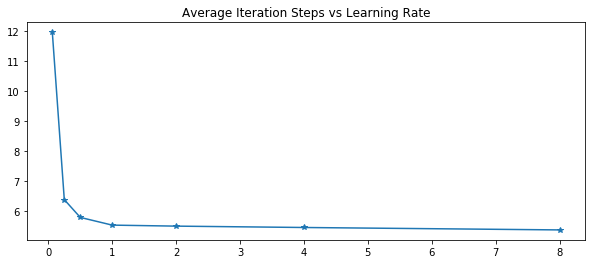

In [19]:
# Exercise #9: use your newly created function PLA_TRAIN_LR to study the effect of the
# learning rate in the perceptron learning algorithm behavior

# For each of the learning rate values provided below, run 10K times the training function
# and compute the average number of iterations needed for the algorithm to finish. Display
# the resulting values and generate a plot of average iteration steps vs learning rates.

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2]]
targets = [1.0,-1.0,1.0,-1.0]

# uses random initial weights and sample sequences
weights = []
sampleseq = []

# use the following values for the learning rate parameter
learning_rates = [0.0625,0.25,0.5,1.0,2.0,4.0,8.0]

# add your code here...
results=[]

for j,lr in enumerate(learning_rates):
    iterations = []

    for m in tqdm(range(10000),desc='lr='+'{:6.4f}'.format(lr)):        
        tmp = pla_train_lr(dataset,targets,weights,sampleseq,lrate=lr)
        iterations.append(tmp.shape[0])
    
    averagesteps = sum(iterations)/len(iterations)
    results.append({'learning rate':lr,'average steps':averagesteps})

results = pd.DataFrame(results)
display(results.T)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(results['learning rate'].values,results['average steps'].values,'*-')
ax.set_title('Average Iteration Steps vs Learning Rate')
plt.show()

lr=8.0000: 100%|█████████████████████████████████| 10000/10000 [00:37<00:00, 266.19it/s]


,0,1,2,3,4,5,6
average steps,12.5995,7.0277,6.3139,5.9878,5.8622,6.0119,6.2237
learning rate,0.0625,0.2500,0.5000,1.0000,2.0000,4.0000,8.0000


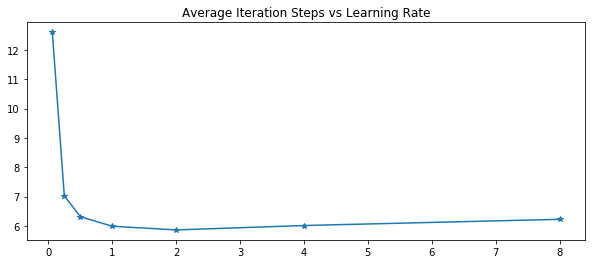

In [21]:
# Exercise #10: repeat the previous exercise but consider this time the new provided dataset,
# which includes an additional data point that makes the classification problem unsolvable
# by means of a single separation boundary line

# Notice that you need to increase the threshold value for the preceptron learning algorithm 
# to stop when only one data sample is misclassified (consider thld=0.9). 

# data samples and target values
dataset = [[1,3],[2,1],[3,4],[4,2],[2,3.5]]
targets = [1.0,-1.0,1.0,-1.0,-1.0]

# uses random initial weights and sample sequences
weights = []
sampleseq = []

# use the following values for the learning rate parameter
learning_rates = [0.0625,0.25,0.5,1.0,2.0,4.0,8.0]

# add your code here...
results=[]

for j,lr in enumerate(learning_rates):
    iterations = []

    for m in tqdm(range(10000),desc='lr='+'{:6.4f}'.format(lr)):        
        tmp = pla_train_lr(dataset,targets,weights,sampleseq,lrate=lr,thld=0.9)
        iterations.append(tmp.shape[0])
    
    averagesteps = sum(iterations)/len(iterations)
    results.append({'learning rate':lr,'average steps':averagesteps})

results = pd.DataFrame(results)
display(results.T)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(results['learning rate'].values,results['average steps'].values,'*-')
ax.set_title('Average Iteration Steps vs Learning Rate')
plt.show()

## Part 3: Term Project Ideas...

In [2]:
# Write two ideas you want to consider for your Term project. For each, provide: a title, 
# a brief description, and some bullet points about why you want to consider it.